#### Imports

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Stats & regression
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
try:
    from statsmodels.stats.het_tests import het_breusch_pagan
except ImportError:
    try:
        from statsmodels.stats.diagnostic import het_breuschpagan as het_breusch_pagan
    except ImportError:
        from statsmodels.sandbox.stats.diagnostic import het_breuschpagan as het_breusch_pagan
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

#### Xamaljob

In [85]:
denmark = pd.read_csv("data/structured_data/denmark_data1.csv")
df = denmark
df.rename(columns={"Real GDP growth": "Real GDP"}, inplace=True)
df = df.dropna()
df = df.set_index("Date")
df.index = pd.DatetimeIndex(df.index, freq=pd.infer_freq(df.index))
df["GDP growth"] = 100 * np.log(df["Real GDP"]).diff()
df.drop(columns=["Real GDP"], inplace=True)
MAX_LAGS = 4
TARGET   = 'GDP growth'

#### Stationarity Test

In [86]:
TARGET = "GDP growth"
features = [c for c in df.columns if c != TARGET]

In [87]:
df_model = df.copy()
differenced_cols = []
print(f"{'Variable':<50} {'ADF':>8}  {'KPSS':>8}  Status")
print("-" * 85)
for col in features:
    adf_p = adfuller(df[col].dropna())[1]
    kpss_p = kpss(df[col].dropna(), regression='c', nlags='auto')[1]
    adf_ok = adf_p < 0.05
    kpss_ok = kpss_p > 0.05

    if adf_ok and kpss_ok:
        status = "Stationary"
    elif not adf_ok and not kpss_ok:
        status = "Non-stationary -> differenced"
    else:
        status = "Mixed -> differenced"

    needs_diff = not (adf_ok and kpss_ok)
    if needs_diff and col != 'GFC':
        df_model[col] = df_model[col].diff()
        differenced_cols.append(col)

    print(f"  {col:<48} p={adf_p:.4f}  p={kpss_p:.4f}  {status}")

Variable                                                ADF      KPSS  Status
-------------------------------------------------------------------------------------
  Retail Sales                                     p=0.3597  p=0.1000  Mixed -> differenced
  NET TRADE                                        p=0.0000  p=0.1000  Stationary
  Inflation (HICP/CPI)                             p=0.9950  p=0.0100  Non-stationary -> differenced
  Unemployment rate                                p=0.2021  p=0.1000  Mixed -> differenced
  Interest rate 10 year government bond yield      p=0.3475  p=0.0100  Non-stationary -> differenced
  Business Confidence Index                        p=0.0752  p=0.0100  Non-stationary -> differenced
  Stock Market Index                               p=0.9987  p=0.0100  Non-stationary -> differenced
  Consumer Confidence Index                        p=0.0387  p=0.0497  Mixed -> differenced
  Oil price                                        p=0.1204  p=0.0443  Non

In [88]:
df_model = df_model.dropna()

# Scale NET TRADE to billions for numerical stability
df_model['NET TRADE'] = df_model['NET TRADE'] / 1e9

print(f"\nDifferenced columns: {differenced_cols}")
print(f"Sample size after differencing: {len(df_model)}")

# Verify stationarity after differencing
print("\nPost-differencing verification:")
for col in differenced_cols:
    adf_p = adfuller(df_model[col].dropna())[1]
    kpss_p = kpss(df_model[col].dropna(), regression='c', nlags='auto')[1]
    ok = "OK" if (adf_p < 0.05 and kpss_p > 0.05) else "Mixed (acceptable at 10%)"
    print(f"  {col:<48} ADF p={adf_p:.4f} | KPSS p={kpss_p:.4f}  {ok}")


Differenced columns: ['Retail Sales', 'Inflation (HICP/CPI)', 'Unemployment rate', 'Interest rate 10 year government bond yield', 'Business Confidence Index', 'Stock Market Index', 'Consumer Confidence Index', 'Oil price', 'ip']
Sample size after differencing: 95

Post-differencing verification:
  Retail Sales                                     ADF p=0.0000 | KPSS p=0.1000  OK
  Inflation (HICP/CPI)                             ADF p=0.6639 | KPSS p=0.1000  Mixed (acceptable at 10%)
  Unemployment rate                                ADF p=0.0002 | KPSS p=0.1000  OK
  Interest rate 10 year government bond yield      ADF p=0.0000 | KPSS p=0.1000  OK
  Business Confidence Index                        ADF p=0.0000 | KPSS p=0.1000  OK
  Stock Market Index                               ADF p=0.0005 | KPSS p=0.0209  Mixed (acceptable at 10%)
  Consumer Confidence Index                        ADF p=0.0000 | KPSS p=0.1000  OK
  Oil price                                        ADF p=0.0000 | KP

#### Multicollinearity Check

In [89]:
# ───────────────────────────────────────────────────────────────
# STEP 2: MULTICOLLINEARITY CHECK (VIF) & CORRELATION SCREEN
# ───────────────────────────────────────────────────────────────
# Variance Inflation Factor > 10 signals harmful collinearity.
# We iteratively remove the worst offender until all VIFs < 10.
# ───────────────────────────────────────────────────────────────

features_sel = list(features)

# Iterative VIF removal
removed_vif = []
while True:
    X_tmp = sm.add_constant(df_model[features_sel])
    vifs = [variance_inflation_factor(X_tmp.values, i+1) for i in range(len(features_sel))]
    max_vif = max(vifs)
    if max_vif <= 10:
        break
    worst = features_sel.pop(vifs.index(max_vif))
    removed_vif.append((worst, max_vif))
    print(f"Removed '{worst}' (VIF = {max_vif:.1f})")

# Display VIF table
vif_df = pd.DataFrame({
    "Feature": features_sel,
    "VIF": [variance_inflation_factor(sm.add_constant(df_model[features_sel]).values, i+1)
            for i in range(len(features_sel))]
}).sort_values("VIF", ascending=False)

In [90]:
print("\nVIF after filtering (all < 10 — no harmful multicollinearity):")
print(vif_df.to_string(index=False))

# Correlation with target
print("\nCorrelation with GDP growth:")
corr = df_model[features_sel + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(corr.to_string())


VIF after filtering (all < 10 — no harmful multicollinearity):
                                    Feature      VIF
                  Business Confidence Index 2.065665
                         Stock Market Index 2.046255
                                  Oil price 1.869980
                  Consumer Confidence Index 1.846645
Interest rate 10 year government bond yield 1.514024
                                        GFC 1.439244
                       Inflation (HICP/CPI) 1.423854
                                         ip 1.372581
                                  NET TRADE 1.369658
                               Retail Sales 1.223064
                          Unemployment rate 1.220148

Correlation with GDP growth:
Business Confidence Index                      0.560702
Oil price                                      0.428193
Stock Market Index                             0.411524
Consumer Confidence Index                      0.313529
ip                                            

### OLS

In [91]:
# ───────────────────────────────────────────────────────────────
# STEP 3: BACKWARD ELIMINATION  (HAC standard errors)
# ───────────────────────────────────────────────────────────────
# We use Newey-West (HAC) SEs with 4 lags (quarterly data) to
# guard against serial correlation and heteroscedasticity.
# At each step we drop the least significant feature (p > 0.10)
# until all remaining features are significant at the 10% level.
# ───────────────────────────────────────────────────────────────

print("Backward Elimination (HAC SEs, threshold p > 0.10)")
print("-" * 65)

while len(features_sel) > 0:
    X = sm.add_constant(df_model[features_sel])
    y = df_model[TARGET]
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

    pvals = model.pvalues.drop('const')
    worst_p = pvals.max()
    if worst_p > 0.10:
        drop = pvals.idxmax()
        print(f"  Drop: {drop:<50} p={worst_p:.4f}")
        features_sel.remove(drop)
    else:
        break


Backward Elimination (HAC SEs, threshold p > 0.10)
-----------------------------------------------------------------
  Drop: NET TRADE                                          p=0.9190
  Drop: Inflation (HICP/CPI)                               p=0.5922
  Drop: Unemployment rate                                  p=0.5782
  Drop: Interest rate 10 year government bond yield        p=0.6081
  Drop: GFC                                                p=0.3808
  Drop: Retail Sales                                       p=0.3460
  Drop: Consumer Confidence Index                          p=0.4093
  Drop: ip                                                 p=0.1549


In [94]:
print(f"\nFinal selected features: {features_sel}")

X = sm.add_constant(df_model[features_sel])
y = df_model[TARGET]

final_model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(final_model.summary())


Final selected features: ['Business Confidence Index', 'Stock Market Index', 'Oil price']
                            OLS Regression Results                            
Dep. Variable:             GDP growth   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.344
Method:                 Least Squares   F-statistic:                     12.01
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.08e-06
Time:                        16:51:24   Log-Likelihood:                -148.37
No. Observations:                  95   AIC:                             304.7
Df Residuals:                      91   BIC:                             315.0
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

#### Train/Test Split & Predictions

In [ ]:
# ───────────────────────────────────────────────────────────────
# Train/Test Split (last 8 observations as test set)
# ───────────────────────────────────────────────────────────────

TEST_SIZE = 19

X_all = sm.add_constant(df_model[features_sel])
y_all = df_model[TARGET]

X_train, X_test = X_all.iloc[:-TEST_SIZE], X_all.iloc[-TEST_SIZE:]
y_train, y_test = y_all.iloc[:-TEST_SIZE], y_all.iloc[-TEST_SIZE:]

print(f"Train: {len(X_train)} obs  ({y_train.index[0].date()} → {y_train.index[-1].date()})")
print(f"Test:  {len(X_test)} obs  ({y_test.index[0].date()} → {y_test.index[-1].date()})")

# Fit on training data only
train_model = sm.OLS(y_train, X_train).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
print(train_model.summary())

# Predict on test set
y_pred = train_model.predict(X_test)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"\n{'─'*50}")
print(f"Out-of-sample metrics (last {TEST_SIZE} quarters):")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}")
print(f"{'─'*50}")

Train: 87 obs  (2000-07-01 → 2022-01-01)
Test:  8 obs  (2022-04-01 → 2024-01-01)
                            OLS Regression Results                            
Dep. Variable:             GDP growth   R-squared:                       0.382
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     11.03
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           3.61e-06
Time:                        19:46:28   Log-Likelihood:                -135.60
No. Observations:                  87   AIC:                             279.2
Df Residuals:                      83   BIC:                             289.1
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------

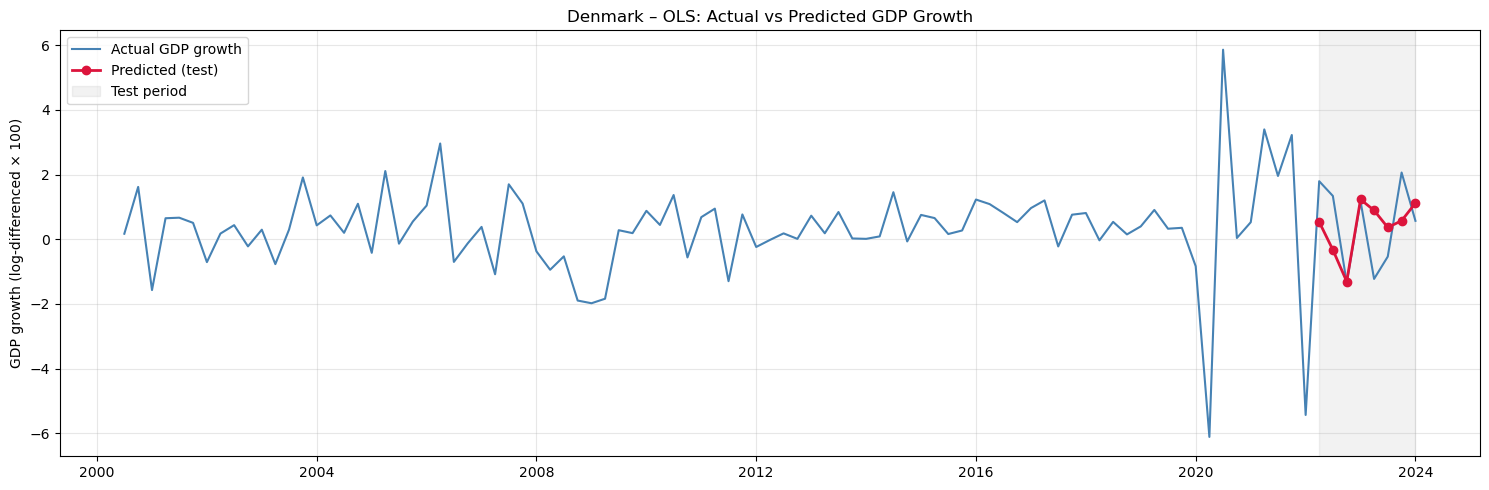

In [113]:
# ───────────────────────────────────────────────────────────────
# Plot: Actual vs Predicted (test period)
# ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(15, 5))

# Plot full actual series
ax.plot(y_all.index, y_all, color='steelblue', label='Actual GDP growth')

# Overlay predictions on test period
ax.plot(y_test.index, y_pred, color='crimson', marker='o', linewidth=2, label='Predicted (test)')

# Shade test region
ax.axvspan(y_test.index[0], y_test.index[-1], color='grey', alpha=0.1, label='Test period')

ax.set_title('Denmark – OLS: Actual vs Predicted GDP Growth')
ax.set_ylabel('GDP growth (log-differenced × 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Lasso Regression

In [114]:
# ───────────────────────────────────────────────────────────────
# Lasso Regression with TimeSeriesSplit CV for alpha selection
# ───────────────────────────────────────────────────────────────
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler

# Use ALL features (let Lasso do its own selection)
all_features = [c for c in df_model.columns if c != TARGET]

X_lasso = df_model[all_features].values
y_lasso = df_model[TARGET].values

# Train/test split (last 8 quarters)
X_train_l, X_test_l = X_lasso[:-TEST_SIZE], X_lasso[-TEST_SIZE:]
y_train_l, y_test_l = y_lasso[:-TEST_SIZE], y_lasso[-TEST_SIZE:]

# Standardise features (fit on train only)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_l)
X_test_sc  = scaler.transform(X_test_l)

# TimeSeriesSplit CV to select optimal alpha
tscv = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-4, 1, 100)

lasso_cv = LassoCV(alphas=alphas, cv=tscv, max_iter=10_000, random_state=42)
lasso_cv.fit(X_train_sc, y_train_l)

print(f"Optimal alpha: {lasso_cv.alpha_:.6f}")
print(f"\nLasso coefficients (standardised):")
coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': lasso_cv.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))
print(f"\nFeatures selected (non-zero): {(lasso_cv.coef_ != 0).sum()} / {len(all_features)}")
print(f"Features zeroed out: {list(np.array(all_features)[lasso_cv.coef_ == 0])}")

Optimal alpha: 0.075646

Lasso coefficients (standardised):
                                    Feature  Coefficient
                  Business Confidence Index     0.466218
                  Consumer Confidence Index     0.188916
                         Stock Market Index     0.175000
                                  Oil price     0.171134
                                         ip     0.108064
                               Retail Sales    -0.018659
                                        GFC    -0.005326
                                  NET TRADE     0.000000
                       Inflation (HICP/CPI)    -0.000000
                          Unemployment rate     0.000000
Interest rate 10 year government bond yield     0.000000

Features selected (non-zero): 7 / 11
Features zeroed out: ['NET TRADE', 'Inflation (HICP/CPI)', 'Unemployment rate', 'Interest rate 10 year government bond yield']


In [115]:
# ───────────────────────────────────────────────────────────────
# Lasso: Out-of-sample predictions & metrics
# ───────────────────────────────────────────────────────────────

y_pred_lasso = lasso_cv.predict(X_test_sc)

rmse_l = np.sqrt(mean_squared_error(y_test_l, y_pred_lasso))
mae_l  = mean_absolute_error(y_test_l, y_pred_lasso)
r2_l   = r2_score(y_test_l, y_pred_lasso)

print(f"Out-of-sample metrics – Lasso (last {TEST_SIZE} quarters):")
print(f"  RMSE : {rmse_l:.4f}")
print(f"  MAE  : {mae_l:.4f}")
print(f"  R²   : {r2_l:.4f}")

# Compare with OLS
print(f"\n{'─'*55}")
print(f"{'Metric':<8} {'OLS':>10} {'Lasso':>10}")
print(f"{'─'*55}")
print(f"{'RMSE':<8} {rmse:>10.4f} {rmse_l:>10.4f}")
print(f"{'MAE':<8} {mae:>10.4f} {mae_l:>10.4f}")
print(f"{'R²':<8} {r2:>10.4f} {r2_l:>10.4f}")
print(f"{'─'*55}")

Out-of-sample metrics – Lasso (last 8 quarters):
  RMSE : 1.3603
  MAE  : 1.1952
  R²   : -0.1622

───────────────────────────────────────────────────────
Metric          OLS      Lasso
───────────────────────────────────────────────────────
RMSE         1.2340     1.3603
MAE          1.0097     1.1952
R²           0.0436    -0.1622
───────────────────────────────────────────────────────


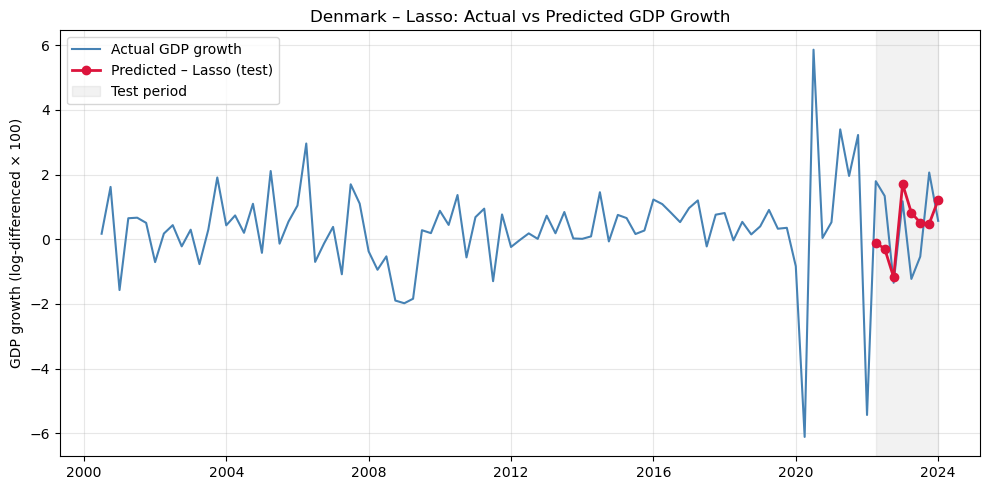

In [116]:
# ───────────────────────────────────────────────────────────────
# Plot: Lasso – Actual vs Predicted (test period)
# ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

test_idx = df_model.index[-TEST_SIZE:]

ax.plot(df_model.index, y_lasso, color='steelblue', label='Actual GDP growth')
ax.plot(test_idx, y_pred_lasso, color='crimson', marker='o', linewidth=2, label='Predicted – Lasso (test)')
ax.axvspan(test_idx[0], test_idx[-1], color='grey', alpha=0.1, label='Test period')

ax.set_title('Denmark – Lasso: Actual vs Predicted GDP Growth')
ax.set_ylabel('GDP growth (log-differenced × 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Ridge Regression

In [117]:
# ───────────────────────────────────────────────────────────────
# Ridge Regression with TimeSeriesSplit CV for alpha selection
# ───────────────────────────────────────────────────────────────
from sklearn.linear_model import RidgeCV

# Reuse the same standardised train/test from the Lasso section
# (X_train_sc, X_test_sc, y_train_l, y_test_l, scaler already defined)

alphas_ridge = np.logspace(-2, 4, 200)

# RidgeCV with TimeSeriesSplit
ridge_cv = RidgeCV(alphas=alphas_ridge, cv=tscv, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_sc, y_train_l)

print(f"Optimal alpha: {ridge_cv.alpha_:.4f}")
print(f"\nRidge coefficients (standardised):")
ridge_coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': ridge_cv.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(ridge_coef_df.to_string(index=False))

Optimal alpha: 51.1143

Ridge coefficients (standardised):
                                    Feature  Coefficient
                  Business Confidence Index     0.313624
                  Consumer Confidence Index     0.196149
                         Stock Market Index     0.194953
                                  Oil price     0.189479
                                         ip     0.138081
                               Retail Sales    -0.077235
                                        GFC    -0.052903
                       Inflation (HICP/CPI)    -0.033949
Interest rate 10 year government bond yield     0.029887
                          Unemployment rate     0.027993
                                  NET TRADE     0.025961


In [118]:
# ───────────────────────────────────────────────────────────────
# Ridge: Out-of-sample predictions & metrics
# ───────────────────────────────────────────────────────────────

y_pred_ridge = ridge_cv.predict(X_test_sc)

rmse_r = np.sqrt(mean_squared_error(y_test_l, y_pred_ridge))
mae_r  = mean_absolute_error(y_test_l, y_pred_ridge)
r2_r   = r2_score(y_test_l, y_pred_ridge)

print(f"Out-of-sample metrics – Ridge (last {TEST_SIZE} quarters):")
print(f"  RMSE : {rmse_r:.4f}")
print(f"  MAE  : {mae_r:.4f}")
print(f"  R²   : {r2_r:.4f}")

# Compare all three
print(f"\n{'─'*65}")
print(f"{'Metric':<8} {'OLS':>10} {'Lasso':>10} {'Ridge':>10}")
print(f"{'─'*65}")
print(f"{'RMSE':<8} {rmse:>10.4f} {rmse_l:>10.4f} {rmse_r:>10.4f}")
print(f"{'MAE':<8} {mae:>10.4f} {mae_l:>10.4f} {mae_r:>10.4f}")
print(f"{'R²':<8} {r2:>10.4f} {r2_l:>10.4f} {r2_r:>10.4f}")
print(f"{'─'*65}")

Out-of-sample metrics – Ridge (last 8 quarters):
  RMSE : 1.3280
  MAE  : 1.1427
  R²   : -0.1076

─────────────────────────────────────────────────────────────────
Metric          OLS      Lasso      Ridge
─────────────────────────────────────────────────────────────────
RMSE         1.2340     1.3603     1.3280
MAE          1.0097     1.1952     1.1427
R²           0.0436    -0.1622    -0.1076
─────────────────────────────────────────────────────────────────


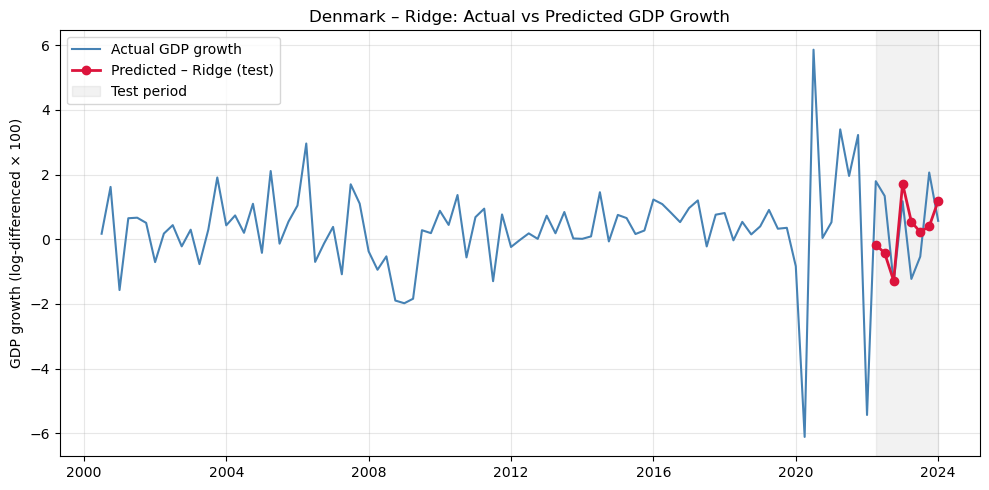

In [119]:
# ───────────────────────────────────────────────────────────────
# Plot: Ridge – Actual vs Predicted (test period)
# ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

test_idx = df_model.index[-TEST_SIZE:]

ax.plot(df_model.index, y_lasso, color='steelblue', label='Actual GDP growth')
ax.plot(test_idx, y_pred_ridge, color='crimson', marker='o', linewidth=2, label='Predicted – Ridge (test)')
ax.axvspan(test_idx[0], test_idx[-1], color='grey', alpha=0.1, label='Test period')

ax.set_title('Denmark – Ridge: Actual vs Predicted GDP Growth')
ax.set_ylabel('GDP growth (log-differenced × 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Elastic Net Regression

In [120]:
# ───────────────────────────────────────────────────────────────
# Elastic Net with TimeSeriesSplit CV for alpha & l1_ratio
# ───────────────────────────────────────────────────────────────
from sklearn.linear_model import ElasticNetCV

# l1_ratio: 0 = pure Ridge, 1 = pure Lasso
l1_ratios = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
alphas_en = np.logspace(-4, 1, 100)

enet_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas_en,
    cv=tscv,
    max_iter=10_000,
    random_state=42
)
enet_cv.fit(X_train_sc, y_train_l)

print(f"Optimal alpha:    {enet_cv.alpha_:.6f}")
print(f"Optimal l1_ratio: {enet_cv.l1_ratio_:.2f}  (0=Ridge, 1=Lasso)")
print(f"\nElastic Net coefficients (standardised):")
enet_coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': enet_cv.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(enet_coef_df.to_string(index=False))
print(f"\nFeatures selected (non-zero): {(enet_cv.coef_ != 0).sum()} / {len(all_features)}")
print(f"Features zeroed out: {list(np.array(all_features)[enet_cv.coef_ == 0])}")

Optimal alpha:    0.075646
Optimal l1_ratio: 0.99  (0=Ridge, 1=Lasso)

Elastic Net coefficients (standardised):
                                    Feature  Coefficient
                  Business Confidence Index     0.465572
                  Consumer Confidence Index     0.189362
                         Stock Market Index     0.175562
                                  Oil price     0.171617
                                         ip     0.108770
                               Retail Sales    -0.019265
                                        GFC    -0.006270
                                  NET TRADE     0.000000
                       Inflation (HICP/CPI)    -0.000000
                          Unemployment rate     0.000000
Interest rate 10 year government bond yield     0.000000

Features selected (non-zero): 7 / 11
Features zeroed out: ['NET TRADE', 'Inflation (HICP/CPI)', 'Unemployment rate', 'Interest rate 10 year government bond yield']


In [121]:
# ───────────────────────────────────────────────────────────────
# Elastic Net: Out-of-sample predictions & metrics
# ───────────────────────────────────────────────────────────────

y_pred_enet = enet_cv.predict(X_test_sc)

rmse_e = np.sqrt(mean_squared_error(y_test_l, y_pred_enet))
mae_e  = mean_absolute_error(y_test_l, y_pred_enet)
r2_e   = r2_score(y_test_l, y_pred_enet)

print(f"Out-of-sample metrics – Elastic Net (last {TEST_SIZE} quarters):")
print(f"  RMSE : {rmse_e:.4f}")
print(f"  MAE  : {mae_e:.4f}")
print(f"  R²   : {r2_e:.4f}")

# Compare all four
print(f"\n{'─'*75}")
print(f"{'Metric':<8} {'OLS':>10} {'Lasso':>10} {'Ridge':>10} {'ElasticNet':>12}")
print(f"{'─'*75}")
print(f"{'RMSE':<8} {rmse:>10.4f} {rmse_l:>10.4f} {rmse_r:>10.4f} {rmse_e:>12.4f}")
print(f"{'MAE':<8} {mae:>10.4f} {mae_l:>10.4f} {mae_r:>10.4f} {mae_e:>12.4f}")
print(f"{'R²':<8} {r2:>10.4f} {r2_l:>10.4f} {r2_r:>10.4f} {r2_e:>12.4f}")
print(f"{'─'*75}")

Out-of-sample metrics – Elastic Net (last 8 quarters):
  RMSE : 1.3603
  MAE  : 1.1947
  R²   : -0.1622

───────────────────────────────────────────────────────────────────────────
Metric          OLS      Lasso      Ridge   ElasticNet
───────────────────────────────────────────────────────────────────────────
RMSE         1.2340     1.3603     1.3280       1.3603
MAE          1.0097     1.1952     1.1427       1.1947
R²           0.0436    -0.1622    -0.1076      -0.1622
───────────────────────────────────────────────────────────────────────────


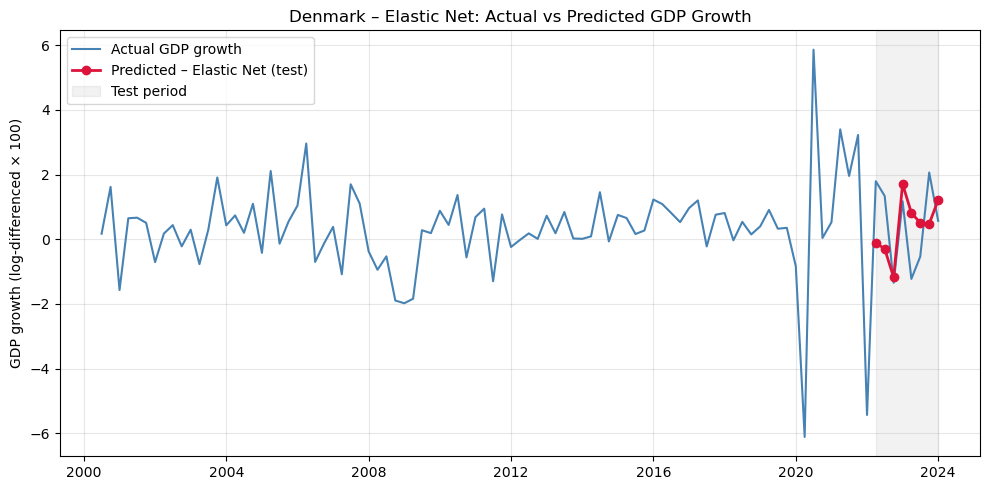

In [122]:
# ───────────────────────────────────────────────────────────────
# Plot: Elastic Net – Actual vs Predicted (test period)
# ───────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

test_idx = df_model.index[-TEST_SIZE:]

ax.plot(df_model.index, y_lasso, color='steelblue', label='Actual GDP growth')
ax.plot(test_idx, y_pred_enet, color='crimson', marker='o', linewidth=2, label='Predicted – Elastic Net (test)')
ax.axvspan(test_idx[0], test_idx[-1], color='grey', alpha=0.1, label='Test period')

ax.set_title('Denmark – Elastic Net: Actual vs Predicted GDP Growth')
ax.set_ylabel('GDP growth (log-differenced × 100)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()